In [31]:
# 获取环境，导库，配置画图面板，导入数据，
# 使用mysql的连接数据库的步骤是，使用pymysql.connect建立连接，使用read_sql方法读取数据,直接用变量保存datafram类型数据，方便后续分析


# pandas: 数据分析的核心库，DataFrame = 内存中的表格
#         命名习惯: import pandas as pd → 后面用 pd.read_sql()、pd.DataFrame()
import pandas as pd

# numpy: 科学计算库，提供高效的数组运算
#         np.select() 向量化条件判断、np.log() 对数变换等
import numpy as np

# matplotlib: Python 最基础的绑图库
#             matplotlib.pyplot 提供类似 MATLAB 的绑图 API
import matplotlib.pyplot as plt
# mticker: 刻度格式化工具，比如把 1000000 显示为 "1,000,000"
import matplotlib.ticker as mticker

# seaborn: 基于 matplotlib 的高级可视化库
#          默认样式比 matplotlib 好看，sns.set_theme() 一键设置全局风格
import seaborn as sns

# datetime: 处理日期时间，datetime.now() 获取当前时间
from datetime import datetime

# 解决字体和负号问题
sns.set_theme(style='whitegrid', context='talk', font='Microsoft YaHei')
# 解决 matplotlib 中文字体下负号显示为方框的问题
plt.rcParams['axes.unicode_minus'] = False

import pymysql
# 与mysql建立连接，之后获取要使用的两张表
conn = pymysql.connect(host='localhost', user='root', password='123456', database='ecommerce_analysis', charset='utf8mb4')
T_USER_BEHAVIOR, T_ORDERS = 'user_behavior', 'orders'
user_behavior_df = pd.read_sql(f'SELECT * FROM {T_USER_BEHAVIOR}', conn)
orders_df = pd.read_sql(f'SELECT * FROM {T_ORDERS}', conn)
print(f'用户行为数据: {len(user_behavior_df):,} 条')
print(f'订单数据:     {len(orders_df):,} 条')

C:\Users\96181\AppData\Local\Temp\ipykernel_4816\4152457576.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  user_behavior_df = pd.read_sql(f'SELECT * FROM {T_USER_BEHAVIOR}', conn)


用户行为数据: 27,897 条
订单数据:     1,851 条


C:\Users\96181\AppData\Local\Temp\ipykernel_4816\4152457576.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders_df = pd.read_sql(f'SELECT * FROM {T_ORDERS}', conn)


In [32]:
user_behavior_df.head()

,id,user_id,action,product_id,create_time
0,1,655,view,30,2025-01-01
1,2,655,add_to_cart,30,2025-01-01
2,3,282,view,97,2025-01-01
3,4,143,view,31,2025-01-01
4,5,143,add_to_cart,31,2025-01-01


In [33]:
orders_df.head()

,order_id,user_id,amount,order_status,create_time
0,1,433,74.15,completed,2025-01-01
1,2,239,528.12,paid,2025-01-01
2,3,734,118.71,completed,2025-01-01
3,4,829,51.49,cancelled,2025-01-01
4,5,7,231.72,paid,2025-01-01


In [34]:
# 展示用户行为日志中每一种交易类型的具体数值
user_behavior_df['action'].value_counts()

action
view           18931
add_to_cart     5711
place_order     1898
pay             1357
Name: count, dtype: int64

In [ ]:
# 按照每个月份进行划分，就是每个月份的漏斗分析


In [35]:
# 日pv,uv计算
# 首先构建一个每日pv，uv的表，默认会将分组的时间当作索引，所以使用reset_index()方法将索引变为普通列，之后使用rename将列名变为date
pv_uv_df = user_behavior_df.groupby(user_behavior_df['create_time'].dt.date).agg(pv=('id', 'count'), uv=('user_id', 'nunique')).reset_index().rename(columns={'create_time': 'date'})

# 计算平均值
avg_pv = pv_uv_df['pv'].mean()
avg_uv = pv_uv_df['uv'].mean()  
print(f'日均 PV: {avg_pv:,.0f}')
print(f'日均 UV: {avg_uv:,.0f}')

# 计算pv/uv比，可以展示每个用户 逛得深不深
print(f'PV/UV 比: {(avg_pv/avg_uv):.1f}（平均每用户浏览页面数）')
pv_uv_df.head(5)

日均 PV: 930
日均 UV: 495
PV/UV 比: 1.9（平均每用户浏览页面数）


,date,pv,uv
0,2025-01-01,1004,531
1,2025-01-02,984,523
2,2025-01-03,1038,531
3,2025-01-04,888,485
4,2025-01-05,802,442


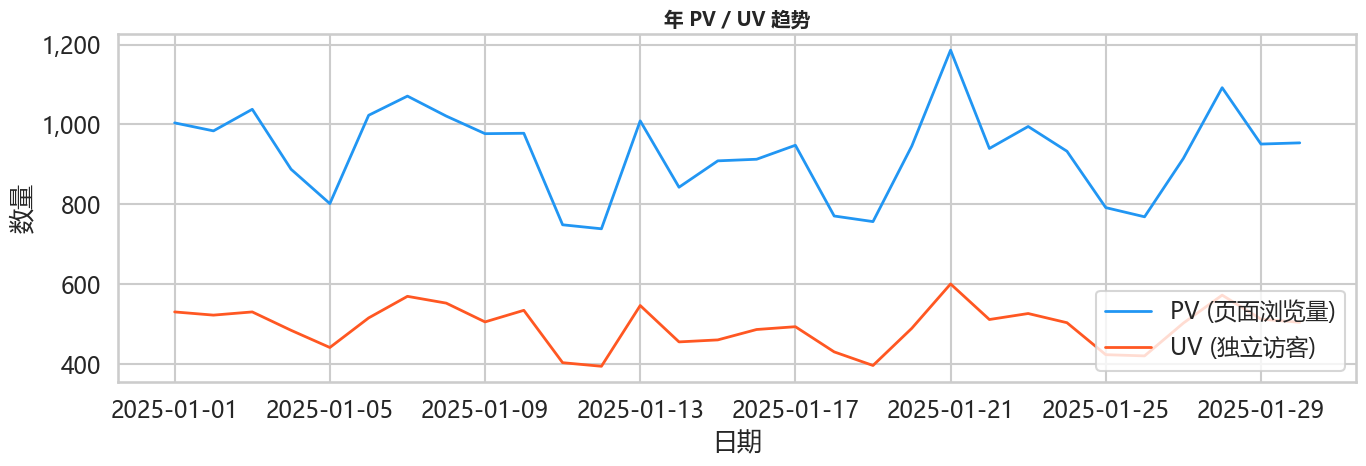

In [ ]:
# 绘制整年的pv,uv趋势图
# 创建画板的时候会返回一个元组，fig是设置画板相关的东西，ax设置画布相关的东西
fig , ax = plt.subplots(figsize=(14,5))
ax.plot( pv_uv_df['date'], pv_uv_df['pv'], color='#2196F3', linewidth=2, label='PV (页面浏览量)')
ax.plot( pv_uv_df['date'], pv_uv_df['uv'], color='#FF5722', linewidth=2, label='UV (独立访客)') 
ax.set_title('年 PV / UV 趋势', fontweight='bold', fontsize=14)
ax.legend(loc='lower right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlabel('日期')
ax.set_ylabel('数量')
# plt设置画板 tight_layout的作用是让画布不会挤到一起去

plt.tight_layout()
plt.show()


In [ ]:
# 付费率分析 ，统计付费的用户有多少人，付费率等于 付费用户/用户数，使用order表中获取(因为订单表才是最终的数据)
len(orders_df)

1851